## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance? 
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting? 
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

# 1.1
Regression and classification are two types of supervised learning tasks that differ in the kind of output they predict. Regression models predict a continuous number value, (integer values like price or weight). On the other hand, classification models predict discrete categories, like color, or type of x category. 

# 1.2
A confusion matrix is a table that summarizes a classification model’s performance by comparing predicted labels to the true labels. Each entry in the confusion matrix shows how many examples of one actual class were predicted as another class, giving you a way of calculating accuracy of a model. The confusion matrix is helpful for evaluating the model's performance because it reveals not only how often the model is correct but also provides extra details like what kinds of mistakes it makes. 

# 1.3
Accuracy is the proportion of predictions that a model gets correct out of all predictions made. However, accuracy can be misleading if the dataset is imbalanced. A biased dataset, for example a set that underrepresents a certain type of data which turns out to be homogenous, may produce high accuracy output but only because the predictions it is making are limited in scope.

# 1.4
Root mean squared error is calculated by taking the square root of the average of the squared differences between predicted values and actual values. In a particular model, RMSE  summarizes how far predictions deviate from true values with larger emphasis on larger errors.

# 1.5
Underfitting occurs when a model doesn't have enough parameters to capture the underlying patterns in the data resulting in high error. Overfitting occurs when a model is too complex and learns irrelevant signals in the training data rather than the true signal. this causes very good training performance, and poor performance on unseen data.

# 1.6 
Splitting data into training and testing sets allows us to evaluate how well a model will perform on unseen data rather than data it was trained on (reduces fitting errors). Selecting the k based on performance on training data helps balance overfitting and underfitting errors. 

# 1.7
Reporting as a prediction - Simpler, since it only states the model’s final decision. However, it hides the model’s uncertainty. a prediction made with 51% confidence appears the same as one made with 99% confidence.
Reporting as a probability distribution - Conveys how confident the model is in each possible class. Probability outputs generally provide richer information than prediction alone.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

**2.1: EDA, Describing Data**

In [127]:
from get_data import download_data

data_dir = download_data()


In [128]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(data_dir, "land_mines.csv"))
df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [129]:
#Basic EDA
df.describe()


,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


In [130]:
df['mine_type'].value_counts()

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

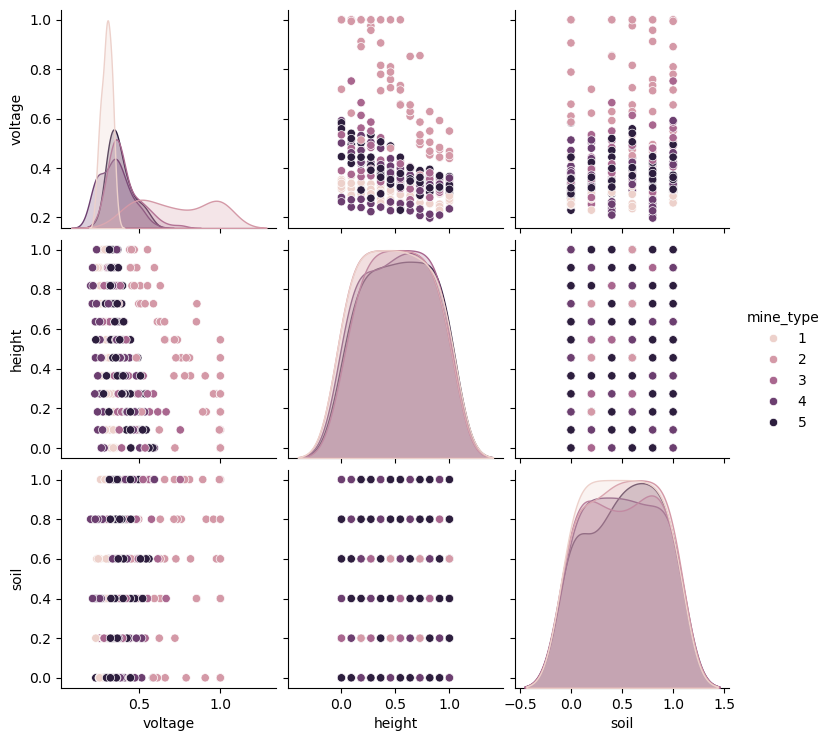

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue='mine_type')
plt.show()

**Splitting sample into training/testing sets**


In [132]:
from sklearn.model_selection import train_test_split

X = df[['voltage','height','soil']]
y = df['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    stratify=y,
    random_state=42
)

In [133]:
#checking to make sure things look right
print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("\nTrain class counts:\n", y_train.value_counts().sort_index())
print("\nTest class counts:\n", y_test.value_counts().sort_index())

Train size: (169, 3) Test size: (169, 3)

Train class counts:
 mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64

Test class counts:
 mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


In [134]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Trying a reasonable range of K vals
k_grid = np.array([ (2*k+1) for k in range(1,50)])

train_accuracies = []
test_accuracies = []

for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    train_accuracies.append(model.score(X_train, y_train))
    test_accuracies.append(model.score(X_test, y_test))

train_accuracies = np.array(train_accuracies)
test_accuracies  = np.array(test_accuracies)

best_k = k_grid[np.argmax(test_accuracies)]
best_test_acc = test_accuracies.max()
best_train_acc = train_accuracies[np.argmax(test_accuracies)]

print("Best k:", best_k)
print("Best test accuracy:", best_test_acc)
print("Train accuracy at best k:", best_train_acc)

Best k: 57
Best test accuracy: 0.41420118343195267
Train accuracy at best k: 0.378698224852071


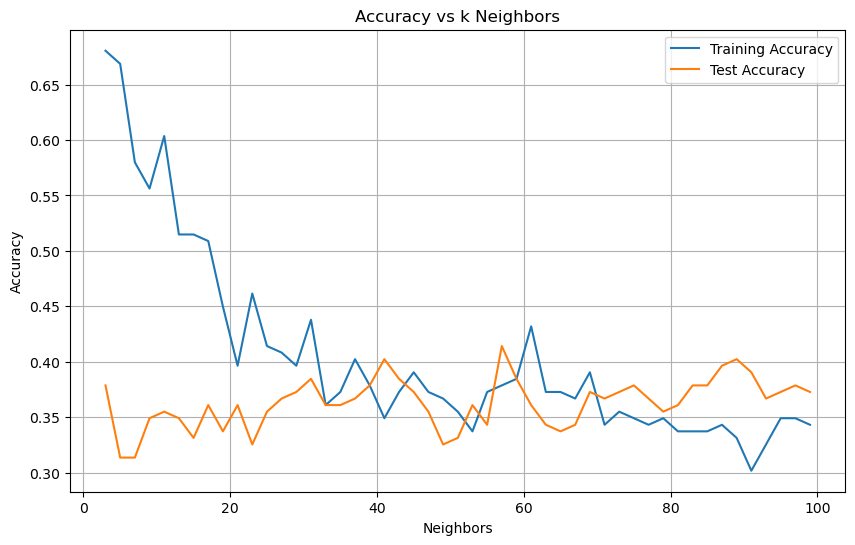

In [135]:
#Visualizing the train/test accuracy by K
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(k_grid, train_accuracies, label="Training Accuracy")
plt.plot(k_grid, test_accuracies, label="Test Accuracy")

plt.xlabel("Neighbors")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k Neighbors")

plt.legend()
plt.grid(True)

plt.show()

To determine an appropriate k, we trained k-nearest neighbor models across a range of odd k values and compared both training and test accuracies. We selected K of 57 based on the fact that this K value maximized accuracy on our test set.






Test accuracy: 0.41420118343195267

Confusion Matrix (rows = actual, columns = predicted):
[[21  0  3  7  5]
 [ 1 24  4  4  2]
 [ 8  1 10 12  2]
 [13  0  7  9  4]
 [14  0  4  8  6]]


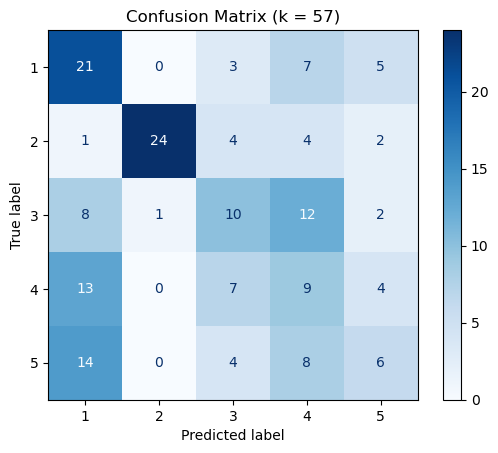

In [136]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Train best model
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train, y_train)

# Predict on test set
y_pred = best_model.predict(X_test)

# Overall accuracy
acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", acc)

# Confusion matrix
labels = sorted(y.unique())  # ensures class order 1–5
cm = confusion_matrix(y_test, y_pred, labels=labels)

print("\nConfusion Matrix (rows = actual, columns = predicted):")
print(cm)

# Plot nicely
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (k = {best_k})")
plt.show()

**Confusion Matrix**
The model achieves an overall test accuracy of approximately 41%, which is definitely higher than random guessing (20%). This indicates that the model finds meaningful insight in the data to predict the correct mine type, but performance is not great overall. 

The confusion matrix shows that while many observations are classified correctly, there is significant overlap between classes, leading to frequent misclassification.

Performance in most accurate for Mine Type 2, followed by mine type 1. Performance is far worse for mine types 3, 4, and 5. 

The model made many mispredictions that mines were Type 1 for some reason. 

**Q2 Part 5:** Advice

 The model is relatively reliable for identifying some mine types (such as type 2), but frequently confuses others, particularly types 3–5, so fully trusting the model's predictions would be unwise. Therefore, this model should be used only to suggest a mine's possible identity rather than as a trustworthy prediction system.


**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [137]:
#q3, part 1
import pandas as pd
import os

cars_df = pd.read_csv(os.path.join(data_dir, "USA_cars_datasets.csv"))

# Keep only required variables
cars_df = cars_df[['price', 'year', 'mileage']]

cars_df.head()

,price,year,mileage
0,6300,2008,274117
1,2899,2011,190552
2,5350,2018,39590
3,25000,2014,64146
4,27700,2018,6654


In [138]:
#checking dimensions and checking for missing vals
print("Shape:", cars_df.shape)

print("\nMissing values per column:")
print(cars_df.isna().sum())

Shape: (2499, 3)

Missing values per column:
price      0
year       0
mileage    0
dtype: int64


per the eda performed above, there are no NAs to handle. Shape is 2499,3

In [139]:
#Maxmin normalizing

def minmax(x):
    u = (x - min(x)) / (max(x) - min(x))
    return u

# Normalize year and mileage 
cars_df[['year', 'mileage']] = cars_df[['year', 'mileage']].apply(minmax)

cars_df.describe()

,price,year,mileage
count,2499.000000,2499.000000,2499.000000
mean,18767.671469,0.930091,0.051377
std,12116.094936,0.073248,0.058654
min,0.000000,0.000000,0.000000
25%,10200.000000,0.914894,0.021088
50%,16900.000000,0.957447,0.034742
75%,25555.500000,0.978723,0.062354
max,84900.000000,1.000000,1.000000


In [140]:
#splitting data 80/20

from sklearn.model_selection import train_test_split

# Features (predictors) and target
X = cars_df[['year', 'mileage']]
y = cars_df['price']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1999, 2)
X_test shape: (500, 2)
y_train shape: (1999,)
y_test shape: (500,)


k =   3 | MSE = 148104157.19


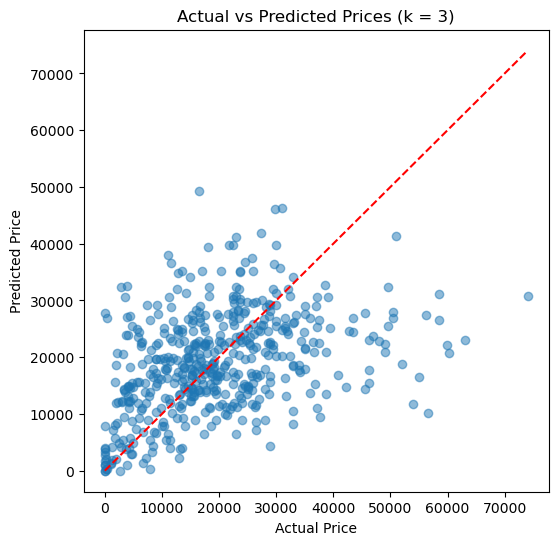

k =  10 | MSE = 117399126.11


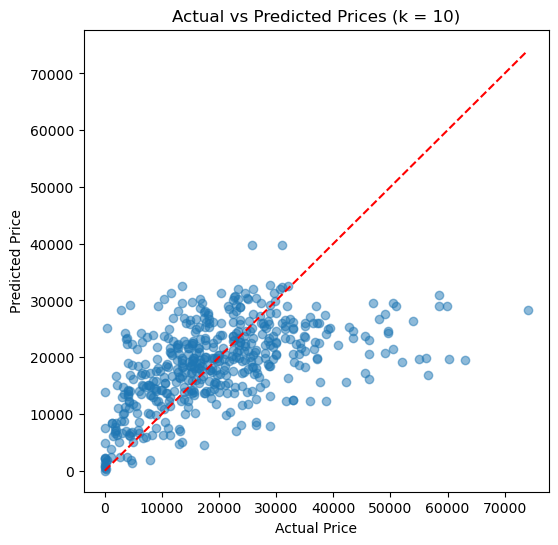

k =  25 | MSE = 112600455.16


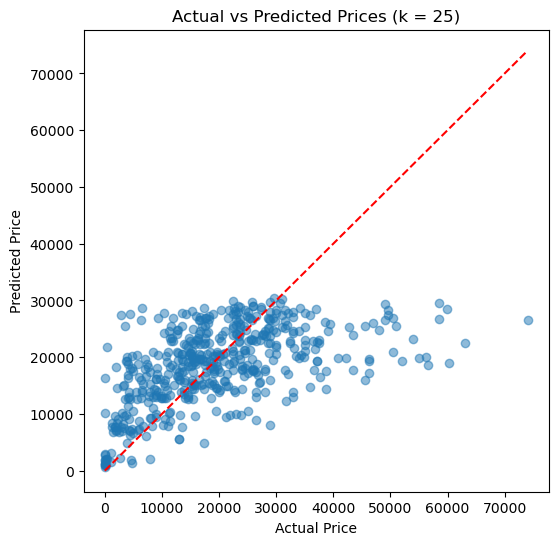

k =  50 | MSE = 110202549.30


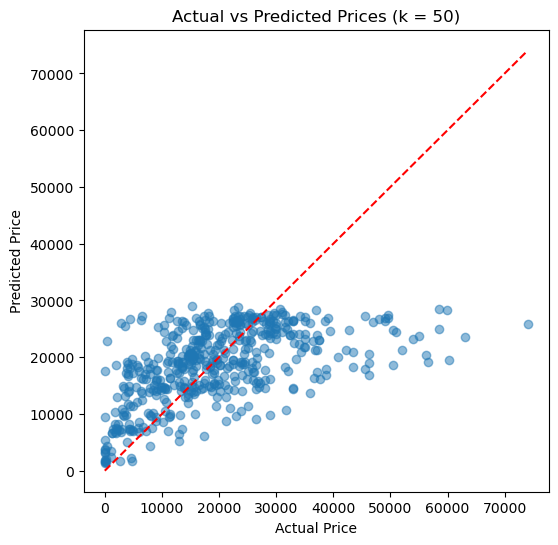

k = 100 | MSE = 112251075.34


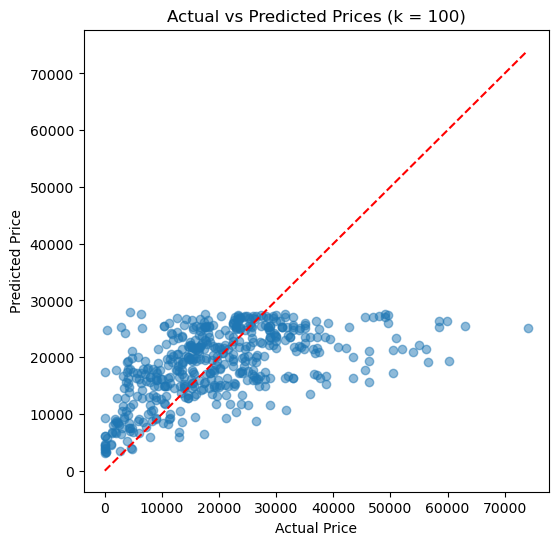

k = 300 | MSE = 114497987.76


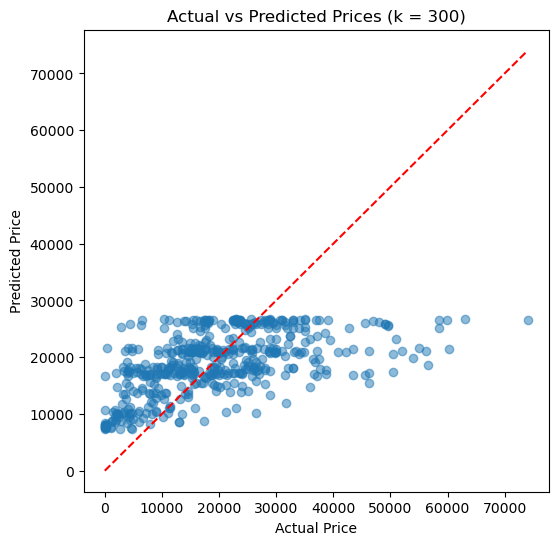

In [141]:
#KNN time
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

k_values = [3, 10, 25, 50, 100, 300]

mse_results = {}

for k in k_values:
    # Create model
    model = KNeighborsRegressor(n_neighbors=k)

    # Train
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Compute MSE
    mse = mean_squared_error(y_test, y_pred)
    mse_results[k] = mse

    print(f"k = {k:>3} | MSE = {mse:.2f}")

    # Scatterplot: actual vs predicted
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"Actual vs Predicted Prices (k = {k})")

    # Ideal prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.show()

Patterns noticed - as k gets extremely large, the data flattens out significantly. On the other hand, the data is all over the place with etremely small K (ex. K=3). 

In [142]:
#To Do: finding the best K

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Try many k values (odd numbers only to avoid ties)
k_grid = np.arange(1, 201, 2)

mse_list = []

for k in k_grid:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)

mse_list = np.array(mse_list)

best_k = k_grid[np.argmin(mse_list)]
best_mse = mse_list.min()

print("Optimal k:", best_k)
print("Lowest MSE:", best_mse)


Optimal k: 49
Lowest MSE: 109968721.06491628


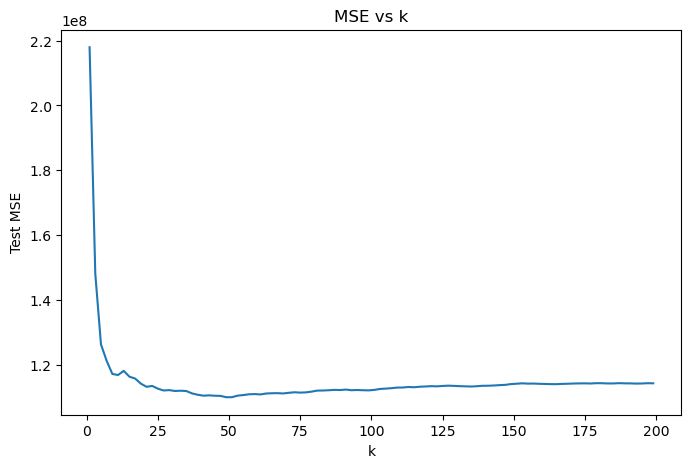

In [143]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(k_grid, mse_list)
plt.xlabel("k")
plt.ylabel("Test MSE")
plt.title("MSE vs k")
plt.show()

**3.6**

Very small k values produced highly variable predictions that closely followed individual training points (overfitting), while very large k values oversmoothed the relationship, causing predictions to collapse toward the overall mean price (underfitting). 

The optimal k balanced these effects, minimizing error by capturing the underlying trend without reacting excessively to noise.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

In [144]:
#4.1
import pandas as pd
import os

# Load dataset
hf_df = pd.read_csv(os.path.join(data_dir, "heart_failure_clinical_records_dataset.csv"))

# Drop 'time'
hf_df = hf_df.drop(columns=['time'])

# Shape
print("Shape:", hf_df.shape)

# Missing values
print("\nMissing values per column:")
print(hf_df.isna().sum())

hf_df.head()

Shape: (299, 12)

Missing values per column:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
DEATH_EVENT                 0
dtype: int64


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,1


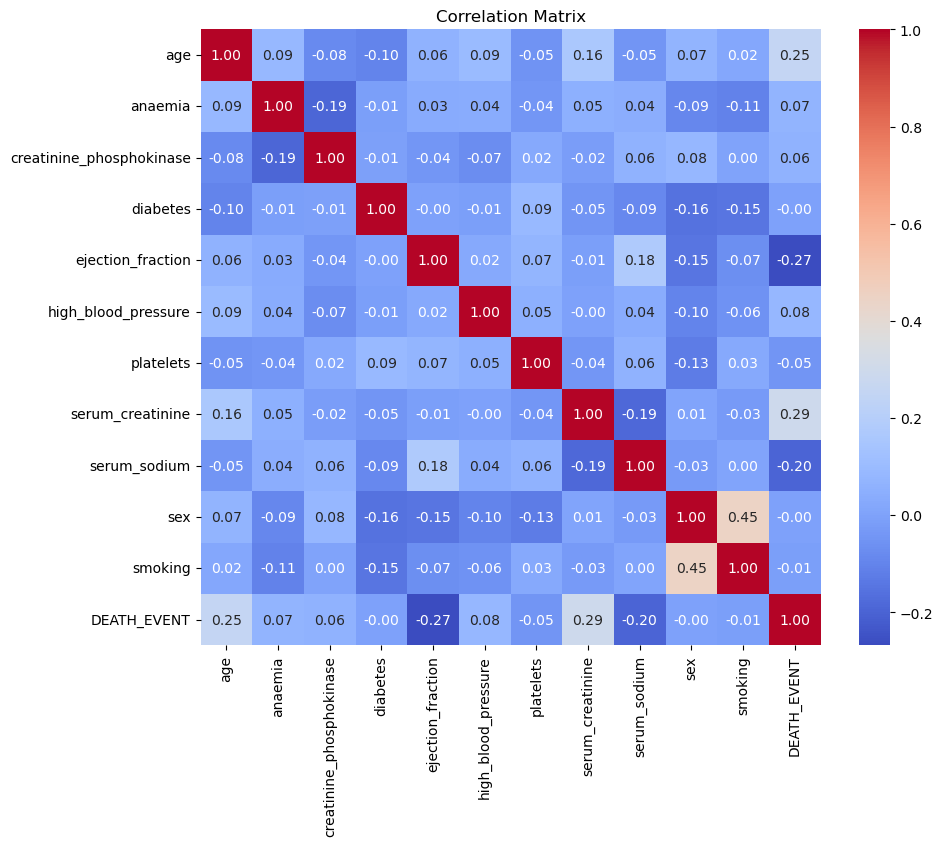


Correlation with DEATH_EVENT:
DEATH_EVENT                 1.000000
serum_creatinine            0.294278
age                         0.253729
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
sex                        -0.004316
smoking                    -0.012623
platelets                  -0.049139
serum_sodium               -0.195204
ejection_fraction          -0.268603
Name: DEATH_EVENT, dtype: float64


In [145]:
#4.2 correlation matrix 
import seaborn as sns
import matplotlib.pyplot as plt

corr = hf_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

print("\nCorrelation with DEATH_EVENT:")
print(corr['DEATH_EVENT'].sort_values(ascending=False))

In [146]:
#4.3 dummy var table

dummy_vars = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']

for var in dummy_vars:
    print(f"\n=== {var} ===")
    print(hf_df.groupby(var)['DEATH_EVENT'].mean())


=== anaemia ===
anaemia
0    0.294118
1    0.356589
Name: DEATH_EVENT, dtype: float64

=== diabetes ===
diabetes
0    0.321839
1    0.320000
Name: DEATH_EVENT, dtype: float64

=== high_blood_pressure ===
high_blood_pressure
0    0.293814
1    0.371429
Name: DEATH_EVENT, dtype: float64

=== sex ===
sex
0    0.323810
1    0.319588
Name: DEATH_EVENT, dtype: float64

=== smoking ===
smoking
0    0.325123
1    0.312500
Name: DEATH_EVENT, dtype: float64


#4.3 continued

anaemia and high blood pressure are associated with higher mortality rates, as the proportion of deaths is greater when these variables equal 1 compared to 0. 

Diabetes, sex, and smoking show minimal differences in death rates between groups. Therefore, anaemia and high blood pressure appear to be the most informative dummy predictors of death among the variables examined.


In [147]:
#4.4
# Build predictor matrix X using most informative variables
X = hf_df[[
    'age',
    'serum_creatinine',
    'ejection_fraction',
    'serum_sodium',
    'anaemia',
    'high_blood_pressure'
]]

# Target variable
y = hf_df['DEATH_EVENT']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (299, 6)
y shape: (299,)


In [148]:
#pt 4.5, maxminning

def minmax(x):
    u = (x - min(x)) / (max(x) - min(x))
    return u

X = X.apply(minmax)

X.describe()

,age,serum_creatinine,ejection_fraction,serum_sodium,anaemia,high_blood_pressure
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,0.378798,0.100436,0.364903,0.675012,0.431438,0.351171
std,0.216269,0.116237,0.179316,0.126071,0.496107,0.478136
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,0.044944,0.242424,0.600000,0.000000,0.000000
50%,0.363636,0.067416,0.363636,0.685714,0.000000,0.000000
75%,0.545455,0.101124,0.469697,0.771429,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [149]:
#4.6 80/20 split

from sklearn.model_selection import train_test_split

# 80/20 split with stratification (important for classification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (239, 6)
X_test shape: (60, 6)
y_train shape: (239,)
y_test shape: (60,)


In [150]:
# finding the optimal K

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Try a range of k values (1 up to ~100 or train size)
k_grid = np.arange(1, 101)

acc_list = []

for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    acc_list.append(acc)

acc_list = np.array(acc_list)

# Best k
best_k = k_grid[np.argmax(acc_list)]
best_acc = acc_list.max()

print("Optimal k:", best_k)
print("Best test accuracy:", best_acc)

Optimal k: 9
Best test accuracy: 0.7


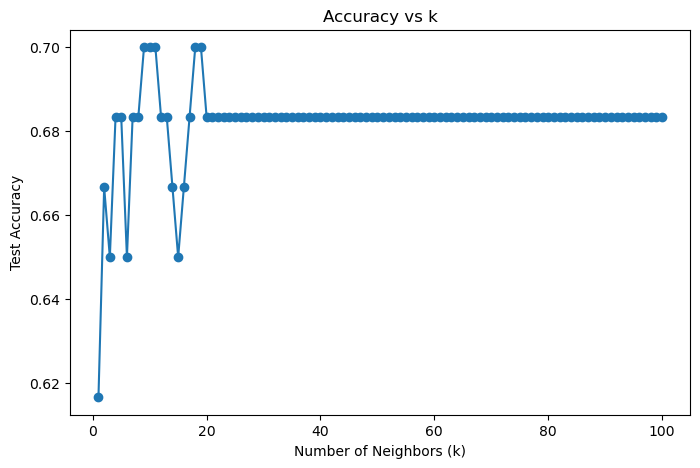

In [151]:
plt.figure(figsize=(8,5))
plt.plot(k_grid, acc_list, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs k")
plt.show()

In [152]:
#4.8 doing it all again, except without time


# time  removed
X_all = hf_df.drop(columns=['DEATH_EVENT'])   
y_all = hf_df['DEATH_EVENT']

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)

X_all shape: (299, 11)
y_all shape: (299,)


In [153]:
#maxminning all predictors


def minmax(x):
    u = (x - min(x)) / (max(x) - min(x))
    return u

X_all = X_all.apply(minmax)

X_all.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000
mean,0.378798,0.431438,0.071299,0.418060,0.364903,0.351171,0.288833,0.100436,0.675012,0.648829,0.32107
std,0.216269,0.496107,0.123793,0.494067,0.179316,0.478136,0.118565,0.116237,0.126071,0.478136,0.46767
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,0.200000,0.000000,0.011929,0.000000,0.242424,0.000000,0.227179,0.044944,0.600000,0.000000,0.00000
50%,0.363636,0.000000,0.028961,0.000000,0.363636,0.000000,0.287186,0.067416,0.685714,1.000000,0.00000
75%,0.545455,1.000000,0.071319,1.000000,0.469697,1.000000,0.337495,0.101124,0.771429,1.000000,1.00000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [154]:
#same 80/20 split
from sklearn.model_selection import train_test_split

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)

In [155]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, accuracy_score

# Try a reasonable range of k (odd helps avoid ties)
k_grid = np.arange(1, 52, 2)  # 1,3,5,...,51

mse_list = []
rmse_list = []
acc_list = []

for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_all, y_train_all)

    y_pred = model.predict(X_test_all)

    mse = mean_squared_error(y_test_all, y_pred)   # for 0/1 labels: this is the error rate
    rmse = np.sqrt(mse)
    acc = accuracy_score(y_test_all, y_pred)

    mse_list.append(mse)
    rmse_list.append(rmse)
    acc_list.append(acc)

mse_list = np.array(mse_list)
rmse_list = np.array(rmse_list)
acc_list = np.array(acc_list)

best_idx = np.argmin(mse_list)
best_k_all = int(k_grid[best_idx])

print("Best k (all variables, by MIN test MSE):", best_k_all)
print("Best test MSE:", mse_list[best_idx])
print("Best test RMSE:", rmse_list[best_idx])
print("Test accuracy at best k:", acc_list[best_idx])

Best k (all variables, by MIN test MSE): 7
Best test MSE: 0.2833333333333333
Best test RMSE: 0.5322906474223771
Test accuracy at best k: 0.7166666666666667


8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? 

(4.8 part 1)

**question 4.8 writeup**

Using the variables selected in parts 4.5-4.7, the model's best k was k=9, test accuracy was about .70, and the RMSE was about .55

For the all variables model, the best k was k=7, test MSE was .2833 repeating, RMSE was .5323, and accuracy was .7167.

This accuracy was marginally better than the model created with just selected predictors, so I would prefer to use the all variables model if i had to predict death events.

To decide what predictors to keep/remove i'm referring back to the correlation table:

Correlation with DEATH_EVENT:
DEATH_EVENT                 1.000000
serum_creatinine            0.294278
age                         0.253729
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
sex                        -0.004316
smoking                    -0.012623
platelets                  -0.049139
serum_sodium               -0.195204
ejection_fraction          -0.268603

To see if i can make a better model I will just use:
serum creatinine
age
high blood pressure

and 

smoking
platelets
serum sodium
ejection fraction

to see if we can remove some of the noise

In [156]:
# Removing some of the messier predictors to see if i can 
# possibly create a better model.

# Selected predictors
X_sel = hf_df[[
    'serum_creatinine',
    'age',
    'high_blood_pressure',
    'smoking',
    'platelets',
    'serum_sodium',
    'ejection_fraction'
]]

y_sel = hf_df['DEATH_EVENT']


# Maxmin 
X_sel_norm = (X_sel - X_sel.min()) / (X_sel.max() - X_sel.min())


# 80/20 split
from sklearn.model_selection import train_test_split

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_sel_norm,
    y_sel,
    test_size=0.20,
    random_state=42,
    stratify=y_sel
)



In [157]:
#tune k for model

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, accuracy_score
import numpy as np

k_values = range(1, 52, 2)   # 1,3,5,...,51

best_k = None
best_mse = float("inf")

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_sel, y_train_sel)   

    y_pred = model.predict(X_test_sel)

    mse = mean_squared_error(y_test_sel, y_pred)  

    if mse < best_mse:
        best_mse = mse
        best_k = k

# train the model
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train_sel, y_train_sel)

y_pred_best = best_model.predict(X_test_sel)

rmse = np.sqrt(best_mse)
acc = accuracy_score(y_test_sel, y_pred_best)

print("Optimal k:", best_k)
print("Test MSE:", best_mse)
print("Test RMSE:", rmse)
print("Test accuracy:", acc)


Optimal k: 5
Test MSE: 0.2833333333333333
Test RMSE: 0.5322906474223771
Test accuracy: 0.7166666666666667


In [158]:
#brute forcing it, trying to find the best subset to generate the highest test accuracy

import numpy as np
import itertools
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


all_predictors = [col for col in hf_df.columns if col not in ['DEATH_EVENT', 'time']]

best_subset = None
best_k = None
best_acc = 0

#normalizing all predictors
X_full = hf_df[all_predictors]
X_full_norm = (X_full - X_full.min()) / (X_full.max() - X_full.min())
y = hf_df['DEATH_EVENT']

#  80/20 split
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full_norm,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Try all subset sizes
for r in range(1, len(all_predictors) + 1):
    for subset in itertools.combinations(all_predictors, r):

        X_train = X_train_full[list(subset)]
        X_test = X_test_full[list(subset)]

        # Tune k for this subset
        for k in range(1, 32, 2):

            model = KNeighborsClassifier(n_neighbors=k)
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)

            if acc > best_acc:
                best_acc = acc
                best_subset = subset
                best_k = k

print("Best predictor subset:", best_subset)
print("Optimal k:", best_k)
print("Best test accuracy:", best_acc)

Best predictor subset: ('age', 'platelets', 'serum_creatinine', 'serum_sodium')
Optimal k: 7
Best test accuracy: 0.8333333333333334


**So to recap, test accuracy at best K:**

part 4.5-4.7 model.  
Test accuracy: 70%. 
RMSE: .55. 

part 4.8 model   
Test accuracy: 71.67%. 
RMSE: 0.532. 

Manually chosen predictors model   
Test accuracy: 71.67%. 
RMSE: 0.532. 


Brute forced best possible subset.  
('age', 'platelets', 'serum_creatinine', 'serum_sodium').   
**Test Accuracy: 83.3%**  
**RMSE: .4082**  




**4.8 part 2: If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.**

For part 4.5-4.7, the optimal model occurred at k = 7, yielding a test MSE of approximately 0.283 (RMSE ≈ 0.53) and an accuracy of about 71.7%. This represents a modest improvement over the model using only selected predictors, which achieved roughly 70% accuracy.

Although adding variables slightly improved performance in part 4.8 the gain was small, indicating that the additional predictors contribute limited new information beyond the most important features. However, the most optimal model achieved test accuracy of over 10% higher with only 4 predictors. Therefore, removing the noise seems to make KNN models perform better, and more variables are not always better.

